<a href="https://colab.research.google.com/github/annaannaR/NOTEBOOKS-FROM-SCHOOL/blob/main/AMS/Machine%20Learning/PART_2/MLP2_Solutions_github.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Assignment 2.1

**Practice with making your own classification model**

Now you get to practice with training and evaluating a classification model.
Below we first generate a dataset to use in this question.

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, shuffle=True, noise=0.4, random_state=1)
df_moons = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_moons["target"] = y

Explore the dataset, choose which classification-model would be most suitable to use, and train and evaluate that model on the dataset.

(You could also choose to train and evaluate several classification-models, and select which performs best).

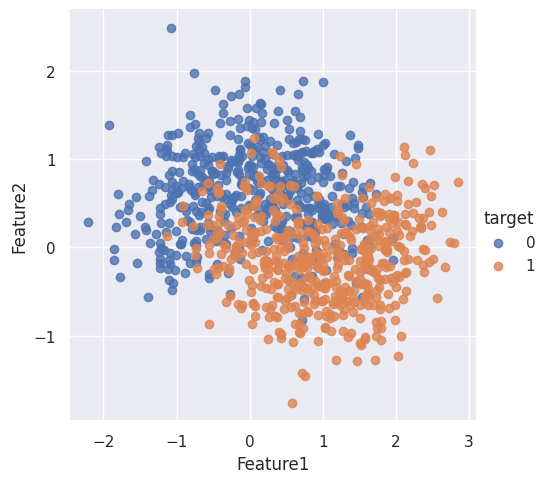

In [ ]:
# Plot the dataset to easily see it's structure
sns.lmplot(x="Feature1", y="Feature2", hue="target", data=df_moons, fit_reg=False)

We see we have a dataset of two features, the values of both reaching from about -2 to 3. The target is either '0' or '1', so two classes (binary classification).
We check the specific values using the describe function:

In [ ]:
df_moons.describe()

,Feature1,Feature2,target
count,1000.000000,1000.000000,1000.00000
mean,0.507216,0.252335,0.50000
std,0.961122,0.623465,0.50025
min,-2.217050,-1.757733,0.00000
25%,-0.175532,-0.183661,0.00000
50%,0.528942,0.255103,0.50000
75%,1.214885,0.696439,1.00000
max,2.850565,2.491881,1.00000


In this case we don't have missing values, or messy columns, so no real data-processing steps need to be taken (convenience of creating your own fictional dataset). We can move on to the modeling part.

In this specific case the explainability of the model is not the most important, I just want to train a highly accurate model. Since the dataset is not too large and the features are comparable in magnitude, let's go with a K-nearest neighbor algorithm.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

We walk through a series of k-values that we have chosen ourselves (1, 11, 31, 51, 75). This series contains the square-root of N (the number of datapoints)=31, and to try it out some smaller and larger k's.

For each k value, we initilialize a new model with that k value. And then we train the model on the train set, make predictions on the test set, and calculate the accuracy (percentage of predictions that predicited the right class).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

accuracy_dict = {}

for i,k in enumerate([1,11,31,51,75]):
  clf = KNeighborsClassifier(k)
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  accuracy = metrics.accuracy_score(y_test, y_pred)
  accuracy_dict[k] = accuracy

accuracy_dict

{1: 0.8,
 11: 0.8333333333333334,
 31: 0.8533333333333334,
 51: 0.8566666666666667,
 75: 0.8566666666666667}

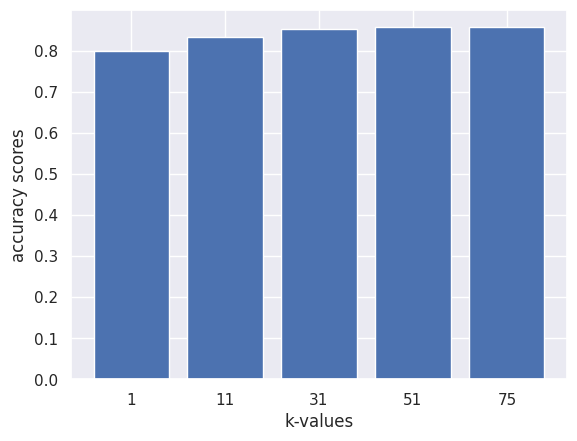

In [ ]:
# Make a plot to see the difference more easily
names = list(accuracy_dict.keys())
values = list(accuracy_dict.values())
plt.bar(range(len(accuracy_dict)), values, tick_label=names)
plt.xlabel("k-values")
plt.ylabel("accuracy scores")
plt.show()

Using 1 neighbor is cleary to brief, and does not teach the model the right pattern. Using more neighbors we see the accuracy increasing.

Using a k-value of 51 and 75 results in the highest accuracy.

For the sake of this example let's stick with the 75-nearest neighbor model (the last model we trained).

Let's take a look at the confusion matrix of this model:

In [ ]:
cm = metrics.confusion_matrix(y_test, y_pred, labels=clf.classes_)

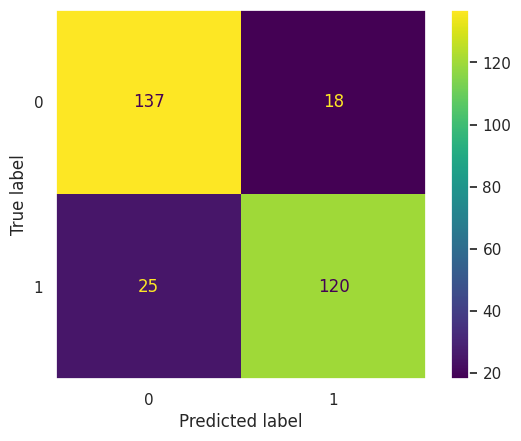

In [ ]:
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=clf.classes_)
disp.plot()
plt.grid(False)
plt.show()

Using the confusion matrix we could also calculate the precision and recall, or even do it automatically using the build-in classification_report function.

#Assignment 2.2
For this assignment we use the wine dataset (winequality-red.csv).
The dataset contains all kinds of data about wines, with a quality label.

The aim is to predict whether a wine is good or bad based on the various measurements.

Each wine in this dataset is assigned a "quality score" between 0 and 10. The quality of a wine is determined by 11 input variables:

* Fixed acidity
* Volatile Acidity
* Citric acid
* Residual sugar
* Chlorides
* Free sulfur dioxide
* Total sulfur dioxide
* Thickness
* pH
* sulfates
* Alcohol

**Question 1a. Import the modules needed for now (numpy, pandas, matplotlib), and mount your Google Drive**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Question 1b. Load the dataset into the notebook.**

In [ ]:
df_wine = pd.read_csv("/content/drive/MyDrive/ADA_datasets/winequality-red.csv")

**Question 2. Data exploration**

Examine the structure of the data. For example: check for missing values, outliers, the distribution of the data. Solve any problems that might need solving.

In [ ]:
print("Rows, columns: " + str(df_wine.shape))
df_wine.head()

Rows, columns: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df_wine.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [ ]:
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


**Question 3. Create some visualizations of the data, such as a histogram of the quality distribution, or a correlation matrix showing how the different variables relate to each other.**

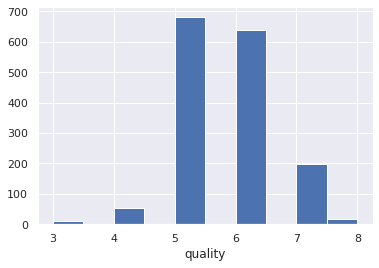

In [ ]:
plt.hist(x=df_wine['quality'])
plt.xlabel("quality")
plt.show()

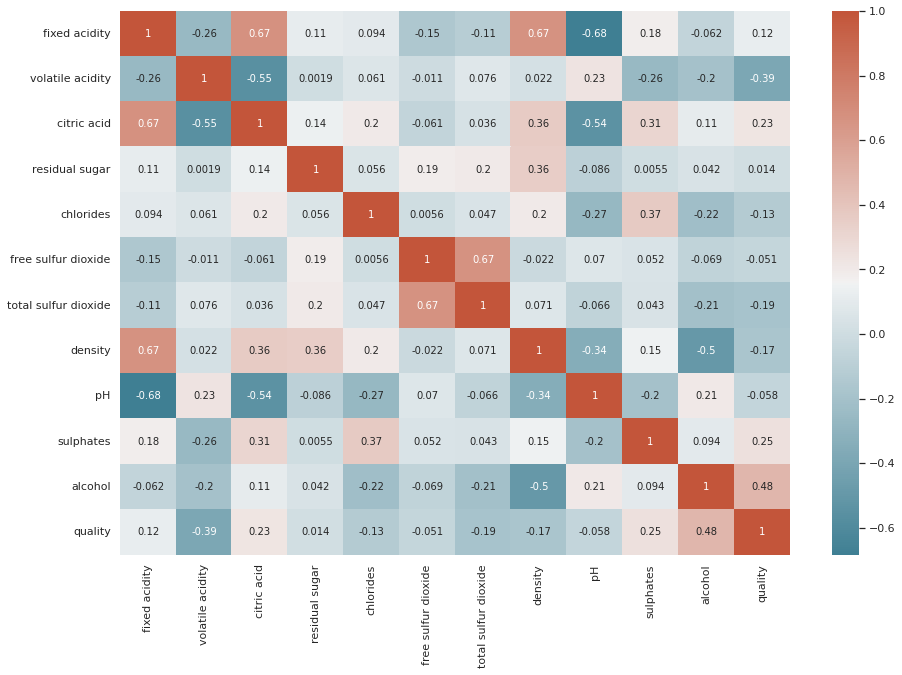

In [ ]:
corr = df_wine.corr()
plt.subplots(figsize=(15,10))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))

**Question 4a. Create a new target column.**

The data in the quality column is scaled from 1 to 10, but we want to make this a classification problem. That means we want to convert the values to a value of 0 (bad wine) or 1 (good wine). Choose a threshold of 7 for a good wine, and create a new column that contains a 0 if the quality is below 7, and a 1 if the wine has a quality of 7 or higher.

In [ ]:
df_wine['goodquality'] = [1 if x >= 7 else 0 for x in df_wine['quality']]

**Question 4b. View the distribution of good and bad wines according to your new classification.**

In [ ]:
df_wine['goodquality'].value_counts()

0    1382
1     217
Name: goodquality, dtype: int64

**Question 5. Split the dataset into features and target.**

In [ ]:
X = df_wine.drop(['quality','goodquality'], axis = 1)
y = df_wine['goodquality']

**Question 6. Split the dataset into a training dataset and a test dataset**

Do this according to a ratio of 0.75 (training) vs. 0.25 (test), and don't forget to set your random_state.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=0)

**Question 7. Scale/standardize the variables in your dataset - be aware not to leak information of the test set to your training set!**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Question 8. Train a decision tree on your training dataset.**

In [ ]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# # to train your model use the argument "random_state=1"
model1 = DecisionTreeClassifier(random_state=1)
model1.fit(X_train_scaled, y_train)
y_pred1 = model1.predict(X_test_scaled)

**Question 9. Evaluate your trained model.**

In [ ]:
print(classification_report(y_test, y_pred1))

**Question 10. Tweak the hyperparameters of your decision tree.**

After reading the blog on Towards Data Science (see the materials in the learning environment, or [here](https://towardsdatascience.com/how-to-tune-a-decision-tree-f03721801680/)) you will have an idea of the possible hyperparameters for your decision tree. Also check the Scikit Learn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

Play with the hyperparameters "max_depth" and "max_leaf_nodes" to see how they affect the performance of your model.

In [ ]:
model2 = DecisionTreeClassifier(random_state=1,max_depth=5,max_leaf_nodes=10)
model2.fit(X_train_scaled, y_train)
y_pred2 = model2.predict(X_test_scaled)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       355
           1       0.47      0.47      0.47        45

    accuracy                           0.88       400
   macro avg       0.70      0.70      0.70       400
weighted avg       0.88      0.88      0.88       400



**Question 11. Which features are most characteristic of a good quality wine?**

In [ ]:
from sklearn import tree

In [ ]:
# Convert binary classes to string datatype for use in plot
class_names_str = [str(i) for i in y]

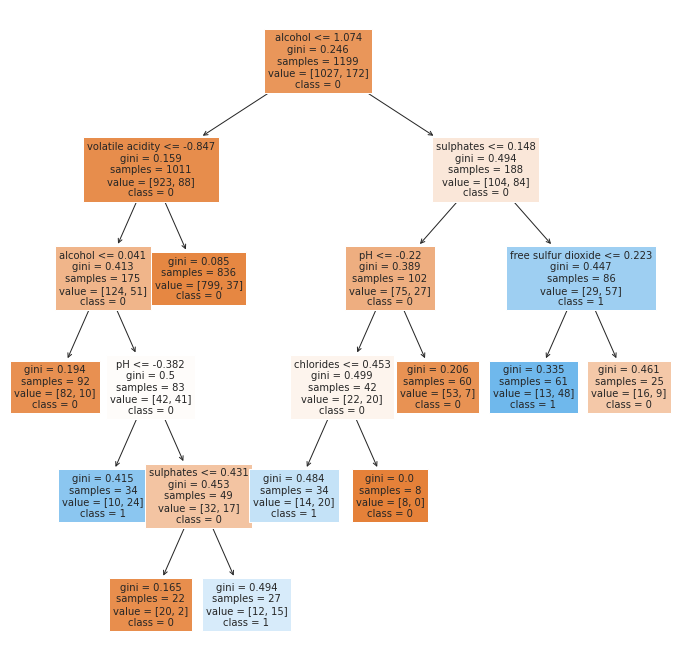

In [ ]:
# Plot tree
plt.figure(figsize=(12,12))
tree.plot_tree(model2,
               fontsize=10,
               feature_names=X.columns,
               class_names=sorted(set(class_names_str)),
               filled=True)
plt.show()

From this tree we can already derive the most important features in predicting good quality wine.

We can also look at the feature_importances:

In [ ]:
feature_importances = model2.feature_importances_

In [ ]:
# Convert to series with feature-names attached
tree_importances = pd.Series(feature_importances, index=X.columns)

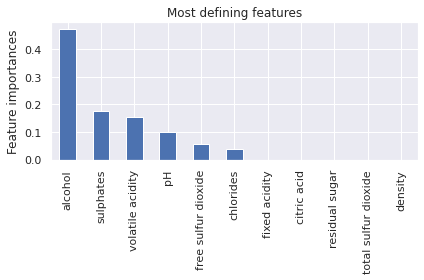

In [ ]:
# Plot
fig, ax = plt.subplots()
tree_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Most defining features")
ax.set_ylabel("Feature importances")
fig.tight_layout()